Plot saved to: bader_charge_transfer_comparison.png


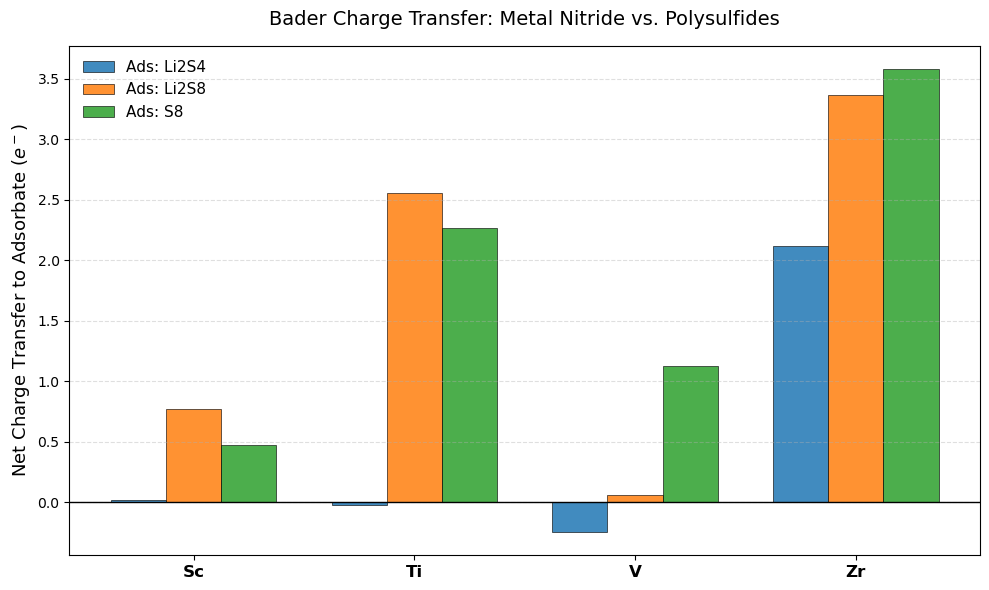

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
# Use your local path
BADER_DIR = "/home/ameer_ubuntu/Git_projects/QE_2/no_u/bader/"
OUTPUT_IMAGE = "bader_charge_transfer_comparison.png"

# Define colors for different regions
COLORS = {
    'adsorbate': '#d62728',   # Red (S8/Polysulfides)
    'surface_metal': '#1f77b4', # Blue (Ti, V, Nb, etc)
    'surface_N': '#2ca02c'     # Green
}

def parse_system_name(filename):
    """Extracts Metal and Adsorbate from filename: NbN_S8_bader.csv"""
    base = os.path.basename(filename).replace("_bader.csv", "")
    parts = base.split("_")
    metal = parts[0].replace("N", "")
    adsorbate = parts[1]
    return metal, adsorbate

def main():
    files = glob.glob(os.path.join(BADER_DIR, "*_bader.csv"))
    if not files:
        print(f"No bader files found in {BADER_DIR}")
        return

    all_data = []

    for f in files:
        df = pd.read_csv(f)
        metal, ads = parse_system_name(f)
        
        # Group by region and sum delta_q
        # We handle 'adsorbate_S', 'adsorbate_Li' by just looking for 'adsorbate'
        summary = df.copy()
        summary['broad_region'] = summary['region'].apply(
            lambda x: 'adsorbate' if 'adsorbate' in str(x) else x
        )
        
        regional_sums = summary.groupby('broad_region')['delta_q'].sum().to_dict()
        
        regional_sums['Metal'] = metal
        regional_sums['Adsorbate'] = ads
        all_data.append(regional_sums)

    # Create master dataframe
    results_df = pd.DataFrame(all_data).fillna(0)
    
    # We want Metals on X-axis, and different bars for different Adsorbates
    adsorbates = sorted(results_df['Adsorbate'].unique())
    metals = ['Sc', 'Ti', 'V', 'Nb', 'Zr'] # Sorted by group/reactivity
    
    # Filter for metals actually found
    metals = [m for m in metals if m in results_df['Metal'].unique()]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    width = 0.25
    x = np.arange(len(metals))

    for i, ads in enumerate(adsorbates):
        subset = results_df[results_df['Adsorbate'] == ads]
        # Match metals to ensure correct ordering
        vals = [subset[subset['Metal'] == m]['adsorbate'].values[0] if m in subset['Metal'].values else 0 for m in metals]
        
        offset = (i - (len(adsorbates)-1)/2) * width
        ax.bar(x + offset, vals, width, label=f"Ads: {ads}", alpha=0.85, edgecolor='black', lw=0.5)

    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels(metals, fontsize=12, fontweight='bold')
    ax.set_ylabel("Net Charge Transfer to Adsorbate ($e^-$)", fontsize=13)
    ax.set_title("Bader Charge Transfer: Metal Nitride vs. Polysulfides", fontsize=14, pad=15)
    ax.axhline(0, color='black', lw=1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(frameon=False, fontsize=11)

    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=300)
    print(f"Plot saved to: {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()

<>:127: SyntaxWarning: invalid escape sequence '\D'
<>:127: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_29837/2934080008.py:127: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("Charge Redistribution $\Delta Q$ ($e^-$)", fontsize=13)


Breakdown plot saved to: bader_element_breakdown.png


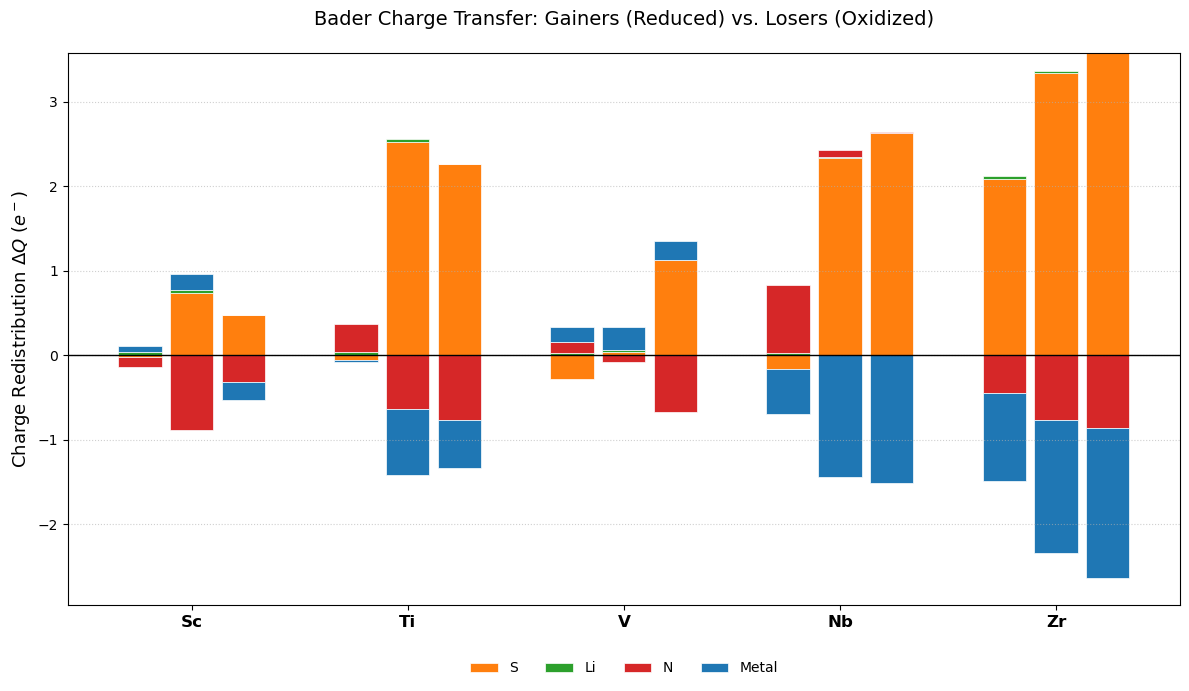

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------
BADER_DIR = "/home/ameer_ubuntu/Git_projects/QE_2/no_u/bader/"
OUTPUT_IMAGE = "bader_element_breakdown.png"

# Color Palette
COLORS = {
    'S':  '#ff7f0e',   # Orange - Main receiver
    'Li': '#2ca02c',   # Green  - Often a donor/receiver mix
    'TM': '#1f77b4',   # Blue   - Transition Metal (donor)
    'N':  '#d62728',   # Red    - Nitrogen
}

# Order of metals for X-axis
METAL_ORDER = ['Sc', 'Ti', 'V', 'Nb', 'Zr']

def parse_metadata(filename):
    """NbN_Li2S8_bader.csv -> (Nb, Li2S8)"""
    base = os.path.basename(filename).replace("_bader.csv", "")
    parts = base.split("_")
    metal_nitride = parts[0]
    metal = metal_nitride[:-1] if metal_nitride.endswith("N") else metal_nitride
    adsorbate = parts[1]
    return metal, adsorbate

def main():
    files = glob.glob(os.path.join(BADER_DIR, "*_bader.csv"))
    if not files:
        # Check current directory as fallback
        files = glob.glob("*_bader.csv")
        if not files:
            print("No bader CSV files found.")
            return

    all_results = []

    for f in files:
        try:
            df = pd.read_csv(f)
            metal, ads = parse_metadata(f)
            
            # Map elements to broad categories for coloring
            # TM = any metal in our list
            def categorize(row):
                elem = str(row['element'])
                if elem in METAL_ORDER: return 'TM'
                if elem in ['S', 'Li', 'N']: return elem
                return 'Other'

            df['cat'] = df.apply(categorize, axis=1)
            
            # Sum delta_q by element category
            sums = df.groupby('cat')['delta_q'].sum().to_dict()
            sums['Metal_Name'] = metal
            sums['Adsorbate'] = ads
            sums['System'] = f"{metal}N_{ads}"
            all_results.append(sums)
        except Exception as e:
            print(f"Error processing {f}: {e}")

    master_df = pd.DataFrame(all_results).fillna(0)
    
    # Filter for metals we want to plot
    master_df = master_df[master_df['Metal_Name'].isin(METAL_ORDER)]
    
    adsorbates = sorted(master_df['Adsorbate'].unique())
    n_ads = len(adsorbates)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bar_width = 0.2
    x_indices = np.arange(len(METAL_ORDER))

    for i, ads in enumerate(adsorbates):
        subset = master_df[master_df['Adsorbate'] == ads]
        
        # Shift bar position for grouping
        offset = (i - (n_ads - 1) / 2) * (bar_width * 1.2)
        
        for j, m_name in enumerate(METAL_ORDER):
            row = subset[subset['Metal_Name'] == m_name]
            if row.empty: continue
            
            current_x = x_indices[j] + offset
            
            # Data for this specific system
            data = {
                'S':  row['S'].values[0],
                'Li': row['Li'].values[0],
                'TM': row['TM'].values[0],
                'N':  row['N'].values[0]
            }

            # Stack logic: Separate positive and negative shifters
            pos_bottom = 0
            neg_bottom = 0
            
            # Sort elements so consistent stacking (Receivers on top, Donors on bottom)
            for label in ['S', 'Li', 'N', 'TM']:
                val = data[label]
                color = COLORS[label]
                
                # Only add label to legend once
                lbl = label if (i == 0 and j == 0) else ""
                if label == 'TM': lbl = "Metal" if lbl else ""

                if val >= 0:
                    ax.bar(current_x, val, bar_width, bottom=pos_bottom, 
                           color=color, edgecolor='white', lw=0.5, label=lbl)
                    pos_bottom += val
                else:
                    ax.bar(current_x, val, bar_width, bottom=neg_bottom, 
                           color=color, edgecolor='white', lw=0.5, label=lbl)
                    neg_bottom += val

    # Formatting
    ax.axhline(0, color='black', lw=1, zorder=2)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(METAL_ORDER, fontsize=12, fontweight='bold')
    ax.set_ylabel("Charge Redistribution $\Delta Q$ ($e^-$)", fontsize=13)
    ax.set_title("Bader Charge Transfer: Gainers (Reduced) vs. Losers (Oxidized)", fontsize=14, pad=20)
    
    # Legend handling (unique labels only)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # Custom legend order
    legend_order = ['S', 'Li', 'N', 'Metal']
    ordered_handles = [by_label[l] for l in legend_order if l in by_label]
    ax.legend(ordered_handles, legend_order, frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.08))

    # Add Adsorbate labels above/below bars
    for i, ads in enumerate(adsorbates):
        ax.text(0, 0, "", label=f"Bar {i+1}: {ads}") # Placeholder for legend if needed
    
    # Grid and cleanup
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=300)
    print(f"Breakdown plot saved to: {OUTPUT_IMAGE}")

if __name__ == "__main__":
    main()